In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.4 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.2

In [2]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import numpy as np

# 1. O mesmo pipeline de transformação usado no treino
transformacao = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Carregando APENAS a divisão de teste (Isso prova o rigor metodológico da equipe)
print("Carregando o Conjunto de Teste Oficial (224x224)...")
test_dataset = PathMNIST(split="test", size=224, download=True, transform=transformacao)

# Podemos usar um batch_size maior aqui porque não vamos treinar (não gasta memória com gradientes)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"✅ Conjunto de Teste carregado! Total de imagens: {len(test_dataset)}")

Carregando o Conjunto de Teste Oficial (224x224)...


100%|██████████| 12.6G/12.6G [01:47<00:00, 118MB/s]


✅ Conjunto de Teste carregado! Total de imagens: 7180


In [3]:
import torch.nn as nn

# 1. O Esqueleto da sua arquitetura campeã
class CNNAutoral(nn.Module):
    def __init__(self, num_classes=9):
        super(CNNAutoral, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# 2. Configurando o dispositivo e instanciando o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_final = CNNAutoral().to(device)

# 3. COLE O CAMINHO DO SEU ARQUIVO DE PESOS AQUI:
pesos_path = "/kaggle/input/datasets/dheriisousa/pesos-rede-autoral/pesos_cnn_autoral.pth"

modelo_final.load_state_dict(torch.load(pesos_path, map_location=device))

# 4. Trava de segurança OBRIGATÓRIA para avaliação final
modelo_final.eval() 
print("✅ Cérebro da rede carregado e congelado para o Teste Final!")

✅ Cérebro da rede carregado e congelado para o Teste Final!


--- INICIANDO A AVALIAÇÃO OFICIAL DE GENERALIZAÇÃO ---
🔥 ACURÁCIA OFICIAL NO TESTE: 89.14%


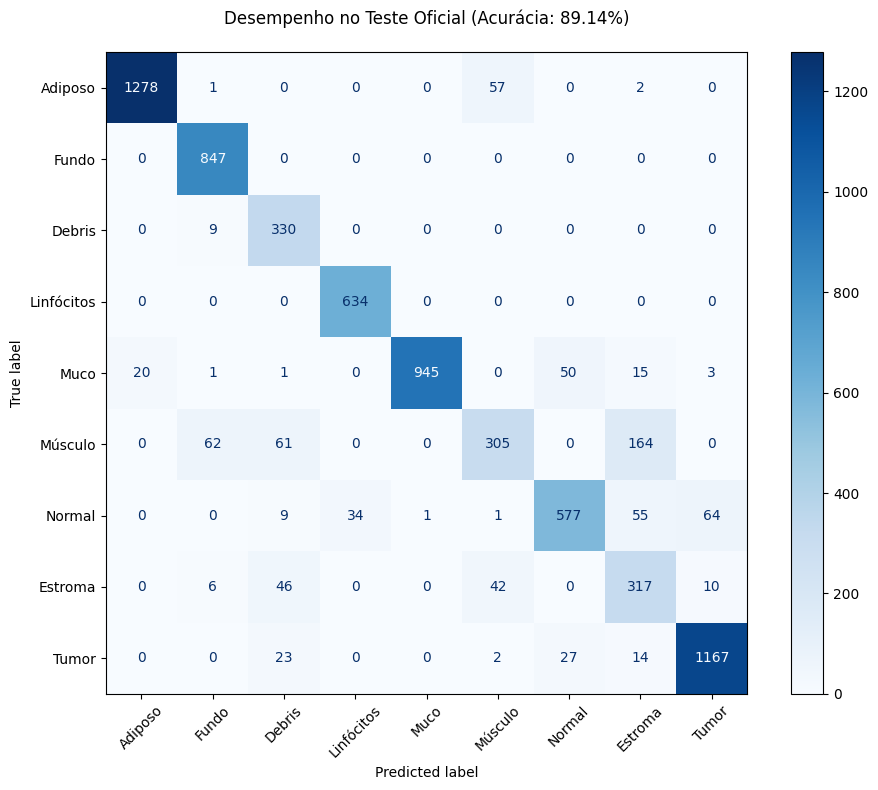

✅ Matriz de Confusão gerada e salva com sucesso!


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("--- INICIANDO A AVALIAÇÃO OFICIAL DE GENERALIZAÇÃO ---")

todas_predicoes = []
todos_rotulos = []
acertos = 0

# torch.no_grad() é crucial aqui para não estourar a RAM
with torch.no_grad():
    for imagens, rotulos in test_loader:
        imagens = imagens.to(device)
        rotulos = rotulos.squeeze().to(device)
        
        saidas = modelo_final(imagens)
        _, predicoes = torch.max(saidas, 1)
        
        acertos += torch.sum(predicoes == rotulos).item()
        
        todas_predicoes.extend(predicoes.cpu().numpy())
        todos_rotulos.extend(rotulos.cpu().numpy())

# Calculando a métrica final exigida no relatório
acuracia_final = (acertos / len(test_dataset)) * 100
print(f"🔥 ACURÁCIA OFICIAL NO TESTE: {acuracia_final:.2f}%")

# Gerando a Matriz de Confusão 9x9
nomes_classes = ['Adiposo', 'Fundo', 'Debris', 'Linfócitos', 
                 'Muco', 'Músculo', 'Normal', 'Estroma', 'Tumor']

matriz = confusion_matrix(todos_rotulos, todas_predicoes)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
disp.plot(cmap='Blues', ax=plt.gca(), xticks_rotation=45)

plt.title(f'Desempenho no Teste Oficial (Acurácia: {acuracia_final:.2f}%)', pad=20)
plt.tight_layout()
plt.savefig("matriz_confusao_teste.png", dpi=300)
plt.show()

print("✅ Matriz de Confusão gerada e salva com sucesso!")